In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Data set for DADS June.csv to Data set for DADS June (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('Data set for DADS June.csv')
df.duplicated().sum()

np.int64(18)

In [ ]:
total_rows,column_count=df.shape
total_duplicates=df.duplicated().sum()
df

,Date,Time,Description,Type,Amount,Balance,Mode,Ref
0,2024-01-01,03:11,AMAZON SELLER SVCS,Debit,₹2462,678275.0,UPI,TXN190872
1,01-Jan-24,05:44,BHIM-BMTC,DR,50.00,681007.0,UPI,TXN143064
2,01-Jan-24,09:35,NEFT-TECHCRUSH LABS-SALARY MAY24,CR,₹84728,484728.0,NEFT,TXN246316
3,2024-01-01,14:07,UPI-AMAN-8934@OKAXIS,Debit,₹1828,-748745.0,UPI,TXN569226
4,01 Jan 2024,14:23,BHIM-BLINKIT,Debit,270.00,680737.0,UPI,TXN968962
...,...,...,...,...,...,...,...,...
1323,2024-06-30,11:53,SWIGGY-INSTAMART,DR,637.00,-311783.0,UPI,TXN274261
1324,30 Jun 2024,16:35,BHIM ZEPTO,DR,693.00,-312476.0,UPI,TXN792601
1325,30/06/24,17:12,UPI-STARBUCKS@AXIS,DR,327.00,-310557.0,UPI,TXN859233
1326,2024-06-30,19:56,POS ZOMATO,DR,₹589,-311146.0,UPI,TXN492729


In [ ]:
#task2:clean
df

,Date,Time,Description,Type,Amount,Balance,Mode,Ref
0,2024-01-01,03:11,AMAZON SELLER SVCS,Debit,₹2462,678275.0,UPI,TXN190872
1,01-Jan-24,05:44,BHIM-BMTC,DR,50.00,681007.0,UPI,TXN143064
2,01-Jan-24,09:35,NEFT-TECHCRUSH LABS-SALARY MAY24,CR,₹84728,484728.0,NEFT,TXN246316
3,2024-01-01,14:07,UPI-AMAN-8934@OKAXIS,Debit,₹1828,-748745.0,UPI,TXN569226
4,01 Jan 2024,14:23,BHIM-BLINKIT,Debit,270.00,680737.0,UPI,TXN968962
...,...,...,...,...,...,...,...,...
1323,2024-06-30,11:53,SWIGGY-INSTAMART,DR,637.00,-311783.0,UPI,TXN274261
1324,30 Jun 2024,16:35,BHIM ZEPTO,DR,693.00,-312476.0,UPI,TXN792601
1325,30/06/24,17:12,UPI-STARBUCKS@AXIS,DR,327.00,-310557.0,UPI,TXN859233
1326,2024-06-30,19:56,POS ZOMATO,DR,₹589,-311146.0,UPI,TXN492729


## Feature 2: Vendor Extractor

To start, let's inspect the unique values in the `Description` column to identify patterns for vendor names.

In [ ]:
print(df['Description'].unique())

['AMAZON SELLER SVCS' 'BHIM-BMTC' 'NEFT-TECHCRUSH LABS-SALARY MAY24'
 'UPI-AMAN-8934@OKAXIS' 'BHIM-BLINKIT' 'BHIM ZEPTO'
 'UPI-UBER-2426@HDFCBANK' 'POS SWIGGY BANGALORE' 'UPI-GROWWPAY@HDFCBANK'
 'OLA ELECTRIC' 'BMS MOVIE TICKETS' 'POS OLA-PRIME' 'SWIGGY-INSTAMART'
 'UPI-STARBUCKS@AXIS' 'UPI-THIRDWAVE@OKAXIS' 'ANI Technologies'
 'BMTC BUS PASS' 'POS TRUFFLES' 'FLIPKART INDIA' 'POS SWIGGY-RESTAURANT'
 'GROFERS INDIA P L' 'POS UBER BANGALORE' 'BANGALORE ELEC SUPPLY'
 'TWC INDIA' 'UPI-BESCOM-BILL@HDFCBANK' 'UPI-AMAN-0816@OKAXIS'
 'ROPPEN TRANSPORTATION' 'OLA CABS' 'POS ZOMATO' 'UPI-AMAZONPAY@HDFCBANK'
 'POS BLINKIT' 'IMPS-RENT-LANDLORD-75500265' 'ZOMATO MEDIA P L'
 'UPI-ANKIT-6430@OKAXIS' 'UPI-OLACABS@HDFCBANK' 'UPI-JIORECHARGE@PAYTM'
 'UPI-CCD@HDFCBANK' 'Swiggy*Order' 'INSTAMART BANGALORE'
 'UPI-ZOMATO-LIMITED@PAYTM' 'AVENUE SUPERMARTS' 'POS HP PETROL STATION'
 'UPI-VIKAS-6060@OKAXIS' 'POS BANGALORE RESTAURANT'
 'UPI-ZERODHA-COIN@AXIS' 'BHIM SWIGGY' 'UPI-BOOKMYSHOW@HDFCBANK'
 'BLINKIT BAN

In [ ]:
vendor_keywords = {
    'Swiggy': ['SWIGGY', 'BUNDL', 'INSTAMART'],
    'Zomato': ['ZOMATO'],
    'Amazon': ['AMAZON', 'AMZN'],
    'Uber': ['UBER'],
    'Ola': ['OLA', 'ANI TECHNOLOGIES', 'OLA ELECTRIC'],
    'Flipkart': ['FLIPKART', 'FKART'],
    'Myntra': ['MYNTRA'],
    'Blinkit': ['BLINKIT'],
    'Zepto': ['ZEPTO'],
    'Starbucks': ['STARBUCKS', 'TATA STARBUCKS', 'COFFEE DAY'],
    'Third Wave Coffee': ['TWC INDIA', 'THIRD WAVE COFFEE', 'UPI-THIRDWAVE'],
    'P2P Transfer': ['UPI-PRIYA', 'UPI-AMAN', 'UPI-VIKAS', 'UPI-ANKIT', 'IMPS-RENT-LANDLORD', 'UPI-NEHA', 'UPI-SNEHA', 'UPI-KARAN'],
    'Cash Withdrawal': ['ATM-WDL'],
    'Netflix': ['NETFLIX'],
    'Spotify': ['SPOTIFY'],
    'Disney Hotstar': ['DISNEY HOTSTAR', 'HOTSTAR'],
    'Airtel': ['AIRTEL POSTPAID', 'BHARTI AIRTEL LTD'],
    'Vi': ['VI POSTPAID', 'VODAFONE IDEA LTD', 'VI-RECHARGE'],
    'Zerodha': ['ZERODHA'],
    'Rapido': ['RAPIDO', 'ROPPEN TRANSPORTATION'],
    'BMTC': ['BMTC', 'TUMMOC-BMTC'],
    'BESCOM': ['BESCOM-BILL', 'BANGALORE ELEC SUPPLY', 'BWSSB', 'BESCOM ELEC'],
    'BigBasket': ['BIGBASKET', 'GROFERS', 'INNOVATIVE RETAIL'],
    'DMart': ['DMART', 'AVENUE SUPERMARTS'],
    'HP Petrol': ['HP PETROL STATION'],
    'BPCL': ['BPCL PETROL PUMP'],
    'Indian Oil': ['INDIAN OIL', 'IOC'],
    'Jio': ['JIORECHARGE', 'RELIANCE JIO', 'JIOFIBER'],
    'BookMyShow': ['BOOKMYSHOW', 'BMS MOVIE TICKETS', 'BIGTREE ENTERTAINMENT'],
    'Nykaa': ['NYKAA', 'FSN E-COMMERCE'],
    'Restaurants/Cafes': ['RESTAURANT', 'EMPIRE RESTAURANT', 'MEGHANA FOODS', 'TRUFFLES', 'CCD', 'DINEOUT'],
    'GrowwPay': ['GROWWPAY', 'GROWW', 'NEXTBILLION-GROWW'],
    'Star India': ['STAR INDIA PVT LTD'],
    'TechCrush Labs': ['TECHCRUSH LABS'],
    'Kiranaka': ['KIRANAKART']
}

print("Vendor keywords dictionary updated.")

Vendor keywords dictionary updated.


In [ ]:
df['vendor_clean'] = df['Description'].apply(extract_vendor)

print("Vendor extraction complete with updated keywords.")

Vendor extraction complete with updated keywords.


In [ ]:
print(f"Number of unique vendors: {df['vendor_clean'].nunique()}")
print("\nTop 10 vendors by count:")
print(df['vendor_clean'].value_counts().head(10))

Number of unique vendors: 35

Top 10 vendors by count:
vendor_clean
Swiggy               248
Zomato               124
Amazon                87
Ola                   87
Restaurants/Cafes     82
Uber                  71
Zepto                 60
Starbucks             59
Rapido                55
Flipkart              48
Name: count, dtype: int64


In [ ]:
category_mapping = {
    'Swiggy': 'Food & Dining',
    'Zomato': 'Food & Dining',
    'Amazon': 'Shopping',
    'Uber': 'Transport',
    'Ola': 'Transport',
    'Flipkart': 'Shopping',
    'Myntra': 'Shopping',
    'Blinkit': 'Groceries',
    'Zepto': 'Groceries',
    'Starbucks': 'Food & Dining',
    'Third Wave Coffee': 'Food & Dining',
    'P2P Transfer': 'Financial',
    'Cash Withdrawal': 'Financial',
    'Netflix': 'Entertainment',
    'Spotify': 'Entertainment',
    'Disney Hotstar': 'Entertainment',
    'Airtel': 'Utilities',
    'Vi': 'Utilities',
    'Zerodha': 'Investments',
    'Rapido': 'Transport',
    'BMTC': 'Transport',
    'BESCOM': 'Utilities',
    'BigBasket': 'Groceries',
    'DMart': 'Groceries',
    'HP Petrol': 'Transport',
    'BPCL': 'BPCL PETROL PUMP',
    'Indian Oil': 'Transport',
    'Jio': 'Utilities',
    'BookMyShow': 'Entertainment',
    'Nykaa': 'Shopping',
    'Restaurants/Cafes': 'Food & Dining',
    'GrowwPay': 'Financial',
    'Star India': 'Entertainment',
    'TechCrush Labs': 'Income',
    'Kiranaka': 'Groceries'
}

def assign_category(vendor):
    return category_mapping.get(vendor, 'Others')

df['category'] = df['vendor_clean'].apply(assign_category)

print("Category mapping complete. New 'category' column added.")

Category mapping complete. New 'category' column added.


In [ ]:
print("Category distribution:")
print(df['category'].value_counts())

Category distribution:
category
Food & Dining       544
Transport           279
Shopping            174
Groceries           170
Financial            51
Entertainment        44
Utilities            44
Investments          14
Income                6
BPCL PETROL PUMP      2
Name: count, dtype: int64


In [ ]:
import numpy as np

# Function to clean and convert amount to numeric
def clean_amount(amount_str):
    if isinstance(amount_str, str):
        cleaned_str = amount_str.replace('₹', '').replace('Rs. ', '').replace(',', '').strip()
        return float(cleaned_str)
    return float(amount_str)

df['Amount_cleaned'] = df['Amount'].apply(clean_amount)

# Map 'Type' to a numeric sign for calculations: Debit as negative, Credit as positive
def map_type_to_sign(row):
    if row['Type'].upper() in ['DEBIT', 'DR']:
        return -abs(row['Amount_cleaned'])
    elif row['Type'].upper() in ['CREDIT', 'CR']:
        return abs(row['Amount_cleaned'])
    return 0 # Should ideally not happen with clean data

df['Amount_signed'] = df.apply(map_type_to_sign, axis=1)

print("Amount column cleaned and signed for calculations.")

Amount column cleaned and signed for calculations.


In [ ]:
# Calculate total credits (income) and debits (expenses)
total_credits = df[df['Type'].str.upper().isin(['CREDIT', 'CR'])]['Amount_cleaned'].sum()
total_debits = df[df['Type'].str.upper().isin(['DEBIT', 'DR'])]['Amount_cleaned'].sum()

print(f"Total Credits (Income): ₹{total_credits:,.2f}")
print(f"Total Debits (Expenses): ₹{total_debits:,.2f}")

# Calculate net spending (or savings/loss)
net_change = total_credits - total_debits
print(f"Net Change (Credits - Debits): ₹{net_change:,.2f}")

Total Credits (Income): ₹509,774.00
Total Debits (Expenses): ₹1,729,708.00
Net Change (Credits - Debits): ₹-1,219,934.00


In [ ]:
# Calculate Savings Rate
# Assuming Savings = Income - Expenses
# And Income is total_credits, Expenses is total_debits

if total_credits > 0:
    savings_rate = ((total_credits - total_debits) / total_credits) * 100
    print(f"Savings Rate: {savings_rate:,.2f}%")
else:
    print("Cannot calculate savings rate as total credits are zero.")

Savings Rate: -239.31%


In [ ]:
print("\nTop 5 Spending Categories (by total debit amount):")
top_categories = df[df['Type'].str.upper().isin(['DEBIT', 'DR'])] \
                    .groupby('category')['Amount_cleaned'].sum() \
                    .sort_values(ascending=False).head(5)
print(top_categories.apply(lambda x: f'₹{x:,.2f}'))


Top 5 Spending Categories (by total debit amount):
category
Shopping         ₹638,210.00
Food & Dining    ₹312,994.00
Financial        ₹217,358.00
Investments      ₹210,000.00
Transport        ₹139,038.00
Name: Amount_cleaned, dtype: object


In [ ]:
print("\nTop 5 Spending Vendors (by total debit amount):")
top_vendors = df[df['Type'].str.upper().isin(['DEBIT', 'DR'])] \
                  .groupby('vendor_clean')['Amount_cleaned'].sum() \
                  .sort_values(ascending=False).head(5)
print(top_vendors.apply(lambda x: f'₹{x:,.2f}'))


Top 5 Spending Vendors (by total debit amount):
vendor_clean
Amazon               ₹348,447.00
Zerodha              ₹210,000.00
Flipkart             ₹191,926.00
P2P Transfer         ₹133,698.00
Restaurants/Cafes    ₹119,944.00
Name: Amount_cleaned, dtype: object


In [ ]:
# Ensure 'Date' is in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extract month as an integer (1 for Jan, 6 for Jun)
df['month'] = df['Date'].dt.month

# Filter for debit transactions for spending analysis
debit_df = df[df['Type'].str.upper().isin(['DEBIT', 'DR'])].copy()

# Create the pivot table: rows = categories, columns = months, values = total spent
month_pivot = debit_df.pivot_table(values='Amount_cleaned', index='category', columns='month', aggfunc='sum')

# Fill NaN values with 0 for categories that had no spending in a given month
month_pivot = month_pivot.fillna(0)

# Rename columns for better readability (e.g., 1 -> Jan)
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun'}
month_pivot = month_pivot.rename(columns=month_names)

print("Monthly spending pivot table created:")
print(month_pivot)

Monthly spending pivot table created:
month              Jan      Feb      Mar      Apr      May      Jun
category                                                           
Entertainment   1176.0   1707.0   3534.0   2808.0      0.0   1176.0
Financial       3094.0      0.0   5621.0   4737.0  23628.0  30742.0
Food & Dining   9667.0  27455.0  13493.0  11797.0  19993.0  10964.0
Groceries       4774.0   4879.0   5394.0   3604.0   6951.0   3831.0
Investments        0.0  15000.0  30000.0  30000.0  30000.0      0.0
Shopping       22055.0  23470.0  13687.0  12880.0  25689.0   4634.0
Transport       3846.0   3414.0  12837.0  11684.0   4097.0   3440.0
Utilities       2329.0      0.0      0.0      0.0    835.0   2072.0


In [ ]:
# Calculate month-on-month percentage change for each category
# We'll calculate (Current Month - Previous Month) / Previous Month * 100

# To find the biggest growth/decline, we compare the last month (June) to the first month (January)
# We'll focus on the overall change from Jan to Jun for simplicity as requested by the hint.

# Get first and last month columns
first_month_col = month_pivot.columns[0]
last_month_col = month_pivot.columns[-1]

# Calculate percentage change from first month to last month
# To avoid division by zero, handle cases where first_month_spending is 0
percentage_change = (month_pivot[last_month_col] - month_pivot[first_month_col]) / month_pivot[first_month_col].replace(0, np.nan) * 100

# Drop NaN values that result from division by zero (no spending in the first month)
percentage_change = percentage_change.dropna()

# Identify category with biggest growth (largest positive percentage change)
biggest_growth_category = percentage_change.idxmax()
biggest_growth_value = percentage_change.max()

# Identify category with biggest decline (largest negative percentage change)
biggest_decline_category = percentage_change.idxmin()
biggest_decline_value = percentage_change.min()

print(f"\nCategory with the BIGGEST month-on-month growth (Jan to Jun): '{biggest_growth_category}' with {biggest_growth_value:.2f}% growth")
print(f"Category with the BIGGEST month-on-month decline (Jan to Jun): '{biggest_decline_category}' with {biggest_decline_value:.2f}% decline")


Category with the BIGGEST month-on-month growth (Jan to Jun): 'Financial' with 893.60% growth
Category with the BIGGEST month-on-month decline (Jan to Jun): 'Shopping' with -78.99% decline


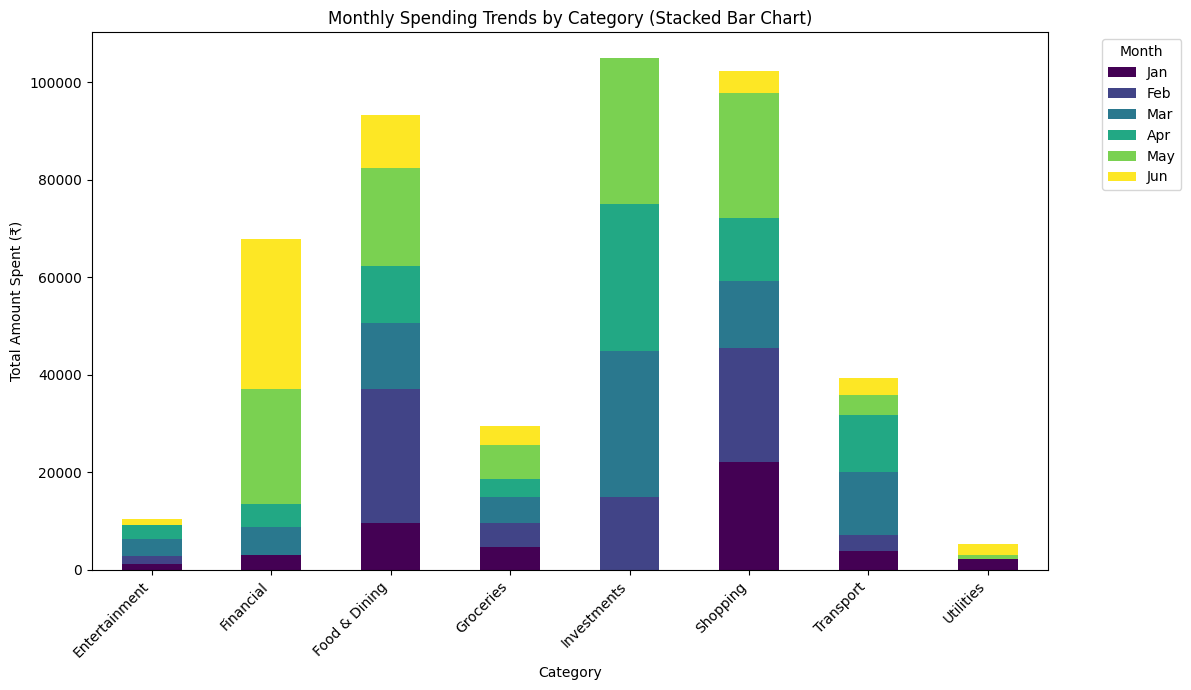

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the monthly spending trends as a stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))
month_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

plt.title('Monthly Spending Trends by Category (Stacked Bar Chart)')
plt.xlabel('Category')
plt.ylabel('Total Amount Spent (₹)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Extract hour from the 'Time' column
df['hour'] = df['Time'].str[:2].astype(int)

# Filter for debit transactions (expenses)
debit_df_time = df[df['Type'].str.upper().isin(['DEBIT', 'DR'])].copy()

# Aggregate spending by category and hour
hour_category_spending = debit_df_time.groupby(['category', 'hour'])['Amount_cleaned'].sum().unstack(fill_value=0)

# Display the first few rows of the aggregated data
print("Hourly spending by category (first 5 categories):")
display(hour_category_spending.head())

Hourly spending by category (first 5 categories):


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
category,,,,,,,,,,,,,,,,,,,,,
BPCL PETROL PUMP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,7707.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Entertainment,562.0,1658.0,1295.0,4029.0,4685.0,745.0,657.0,1468.0,1463.0,0.0,...,1473.0,0.0,1881.0,0.0,1270.0,1852.0,1426.0,119.0,343.0,0.0
Financial,4883.0,0.0,0.0,0.0,3834.0,4496.0,7717.0,0.0,4329.0,17662.0,...,20828.0,0.0,7361.0,4685.0,5864.0,5771.0,3548.0,4004.0,6185.0,3628.0
Food & Dining,3798.0,4526.0,2710.0,4165.0,2618.0,5614.0,1276.0,2210.0,14442.0,9054.0,...,6284.0,11169.0,20551.0,12215.0,27637.0,26499.0,49107.0,19560.0,12065.0,8147.0
Groceries,4754.0,2938.0,3049.0,10796.0,1937.0,1448.0,6052.0,252.0,4265.0,11185.0,...,5644.0,3014.0,6105.0,948.0,5434.0,8546.0,9601.0,9707.0,3405.0,3299.0


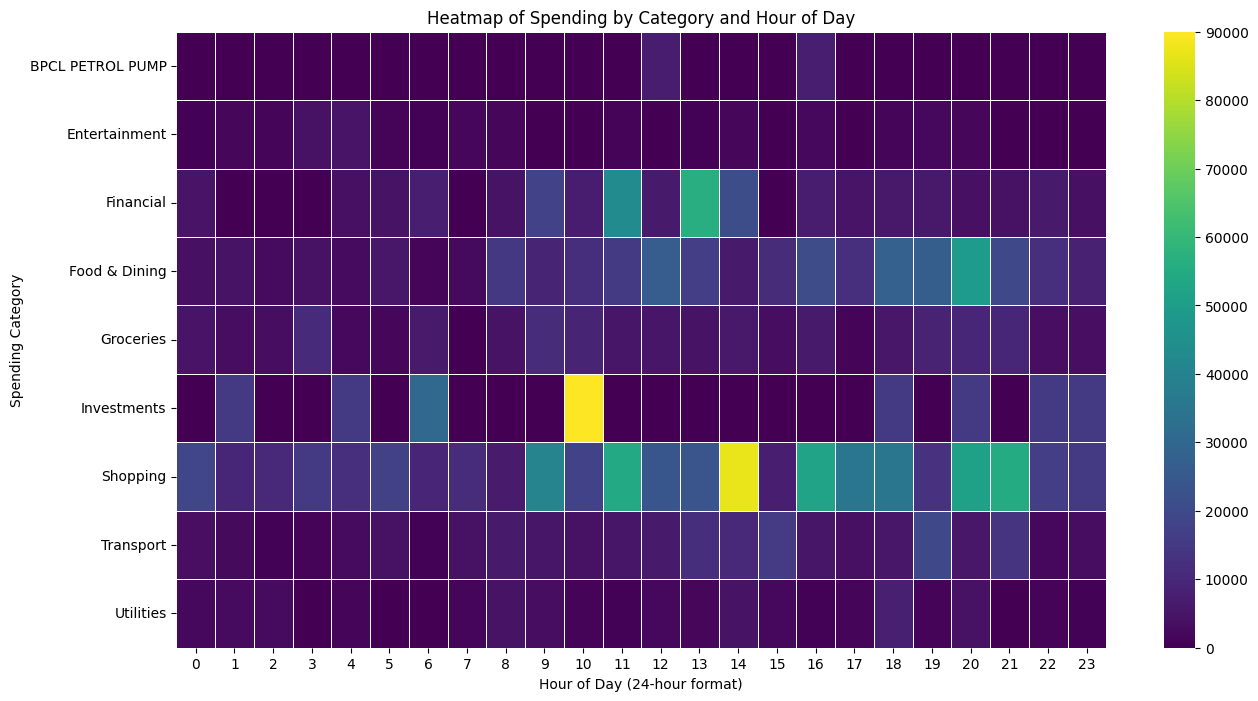

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(hour_category_spending, cmap='viridis', annot=False, fmt=".0f", linewidths=.5)
plt.title('Heatmap of Spending by Category and Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Spending Category')
plt.show()

In [ ]:
# Filter for debit transactions (expenses)
df_debit = df[df['Type'].str.upper().isin(['DEBIT', 'DR'])].copy()

# Calculate mean and standard deviation of 'Amount_cleaned' for each category
df_debit['category_mean'] = df_debit.groupby('category')['Amount_cleaned'].transform('mean')
df_debit['category_std'] = df_debit.groupby('category')['Amount_cleaned'].transform('std')

# Calculate Z-score
# Handle cases where standard deviation might be zero (e.g., only one transaction in a category)
df_debit['z_score'] = (df_debit['Amount_cleaned'] - df_debit['category_mean']) / df_debit['category_std'].replace(0, np.nan)

# Drop NaNs that result from categories with zero standard deviation (or single transactions)
df_debit['z_score'] = df_debit['z_score'].fillna(0)

# Sort by absolute z_score in descending order to find the top anomalies
anomalies = df_debit.sort_values(by='z_score', ascending=False)

# Display the top 5 anomalies with relevant columns
print("\nTop 5 Anomalous Transactions (high positive Z-score):")
display(anomalies[['Date', 'Description', 'vendor_clean', 'category', 'Amount_cleaned', 'z_score']].head(5))


Top 5 Anomalous Transactions (high positive Z-score):


,Date,Description,vendor_clean,category,Amount_cleaned,z_score
414,2024-02-26,POS BANGALORE RESTAURANT,Restaurants/Cafes,Food & Dining,8383.0,10.167014
1271,NaT,POS DINEOUT,Restaurants/Cafes,Food & Dining,7935.0,9.583634
653,NaT,POS MEGHANA FOODS,Restaurants/Cafes,Food & Dining,7931.0,9.578425
464,NaT,POS TRUFFLES,Restaurants/Cafes,Food & Dining,7441.0,8.940354
49,NaT,POS BANGALORE RESTAURANT,Restaurants/Cafes,Food & Dining,7314.0,8.774976


## Feature 8: Spending Archetype Detection (Revised Rules)

Now, let's apply the specific rules provided for spending archetype detection. We will evaluate each rule and determine if Rahul's spending patterns match the archetype.

In [ ]:
archetype_matches = {}

# Filter for debit transactions for calculations involving percentages of debits
df_debits_only = df[df['Type'].str.upper().isin(['DEBIT', 'DR'])]
total_debits_amount = df_debits_only['Amount_cleaned'].sum()

# Helper function to get percentage of total debits for given categories
def get_category_percentage_of_debits(categories):
    category_debits = df_debits_only[df_debits_only['category'].isin(categories)]['Amount_cleaned'].sum()
    return (category_debits / total_debits_amount) * 100 if total_debits_amount > 0 else 0

# Helper function to get percentage of total debits for given vendors
def get_vendor_percentage_of_debits(vendors):
    vendor_debits = df_debits_only[df_debits_only['vendor_clean'].isin(vendors)]['Amount_cleaned'].sum()
    return (vendor_debits / total_debits_amount) * 100 if total_debits_amount > 0 else 0

# --- THE FOODIE ---
foodie_categories = ['Food & Dining'] # Assuming 'Food Delivery', 'Restaurants', 'Cafe' are covered by Food & Dining
foodie_percentage = get_category_percentage_of_debits(foodie_categories)
archetype_matches['THE FOODIE'] = foodie_percentage > 25
print(f"THE FOODIE (Food & Dining > 25% of debits): {archetype_matches['THE FOODIE']} ({foodie_percentage:.2f}%)")

# --- THE QUICK COMMERCE JUNKIE ---
quick_commerce_vendors = ['Blinkit', 'Zepto', 'BigBasket', 'Groceries'] # 'Swiggy Instamart' would also be Swiggy
quick_commerce_percentage = get_vendor_percentage_of_debits(quick_commerce_vendors)
archetype_matches['THE QUICK COMMERCE JUNKIE'] = quick_commerce_percentage > 15
print(f"THE QUICK COMMERCE JUNKIE (Quick Commerce > 15% of debits): {archetype_matches['THE QUICK COMMERCE JUNKIE']} ({quick_commerce_percentage:.2f}%)")

# --- THE SHOPAHOLIC ---
ecommerce_vendors = ['Amazon', 'Flipkart', 'Myntra', 'Nykaa']
ecommerce_percentage = get_vendor_percentage_of_debits(ecommerce_vendors)
archetype_matches['THE SHOPAHOLIC'] = ecommerce_percentage > 15
print(f"THE SHOPAHOLIC (E-commerce > 15% of debits): {archetype_matches['THE SHOPAHOLIC']} ({ecommerce_percentage:.2f}%)")

# --- THE INVESTOR ---
investment_category = ['Investments']
investment_percentage = get_category_percentage_of_debits(investment_category)
archetype_matches['THE INVESTOR'] = investment_percentage > 15
print(f"THE INVESTOR (Investments > 15% of debits): {archetype_matches['THE INVESTOR']} ({investment_percentage:.2f}%)")

# --- THE LATE-NIGHT SNACKER ---
food_delivery_vendors = ['Swiggy', 'Zomato']
food_delivery_df = df_debits_only[df_debits_only['vendor_clean'].isin(food_delivery_vendors)].copy()

if not food_delivery_df.empty:
    # Convert time to datetime objects for easier comparison
    food_delivery_df['Time_dt'] = pd.to_datetime(food_delivery_df['Time'], format='%H:%M', errors='coerce').dt.time

    # Filter for late night hours (21:00 to 02:00 next day)
    # This needs careful handling for time crossing midnight
    late_night_transactions = food_delivery_df[
        ((food_delivery_df['Time_dt'] >= pd.to_datetime('21:00').time()) & (food_delivery_df['Time_dt'] <= pd.to_datetime('23:59').time())) |
        ((food_delivery_df['Time_dt'] >= pd.to_datetime('00:00').time()) & (food_delivery_df['Time_dt'] < pd.to_datetime('02:00').time()))
    ]

    total_food_delivery_count = len(food_delivery_df)
    late_night_count = len(late_night_transactions)
    late_night_percentage = (late_night_count / total_food_delivery_count) * 100 if total_food_delivery_count > 0 else 0
else:
    late_night_percentage = 0

archetype_matches['THE LATE-NIGHT SNACKER'] = late_night_percentage > 50
print(f"THE LATE-NIGHT SNACKER (Food Delivery between 21:00-02:00 > 50%): {archetype_matches['THE LATE-NIGHT SNACKER']} ({late_night_percentage:.2f}%)")

# --- THE CAB COMMUTER ---
transport_category = ['Transport']
transport_percentage = get_category_percentage_of_debits(transport_category)
archetype_matches['THE CAB COMMUTER'] = transport_percentage > 10
print(f"THE CAB COMMUTER (Transport > 10% of debits): {archetype_matches['THE CAB COMMUTER']} ({transport_percentage:.2f}%)")

# --- THE SUBSCRIPTION LOVER ---
subscription_vendors = ['Netflix', 'Spotify', 'Disney Hotstar', 'Airtel', 'Vi', 'Jio']
active_subscriptions = df_debits_only[df_debits_only['vendor_clean'].isin(subscription_vendors)]['vendor_clean'].nunique()
archetype_matches['THE SUBSCRIPTION LOVER'] = active_subscriptions >= 5
print(f"THE SUBSCRIPTION LOVER (5 or more distinct subscription vendors active): {archetype_matches['THE SUBSCRIPTION LOVER']} ({active_subscriptions} active)")

# --- THE YOLO SPENDER ---
# total_credits and total_debits are available from previous cells
# savings_rate is also available
if total_credits > 0:
    yolo_spender_condition = ((total_credits - total_debits) / total_credits) * 100 < 10
else:
    # If no credits, savings rate is effectively very low or negative
    yolo_spender_condition = True
archetype_matches['THE YOLO SPENDER'] = yolo_spender_condition
print(f"THE YOLO SPENDER (Savings rate < 10%): {archetype_matches['THE YOLO SPENDER']} ({savings_rate:.2f}%)")

# --- THE DISCIPLINED SAVER ---
# total_credits and total_debits are available from previous cells
# savings_rate is also available
if total_credits > 0:
    disciplined_saver_condition = ((total_credits - total_debits) / total_credits) * 100 > 40
else:
    disciplined_saver_condition = False
archetype_matches['THE DISCIPLINED SAVER'] = disciplined_saver_condition
print(f"THE DISCIPLINED SAVER (Savings rate > 40%): {archetype_matches['THE DISCIPLINED SAVER']} ({savings_rate:.2f}%)")

# --- Custom Archetype: THE BANGALORE BREWERY HOPPER ---
# Rule: More than 3 distinct 'Restaurants/Cafes' vendors appear more than once in the debit transactions, AND Food & Dining debits > 10% of total debits.
brewery_candidates_df = df_debits_only[(df_debits_only['category'] == 'Food & Dining')].copy()

# Count occurrences of each 'Restaurants/Cafes' vendor
vendor_counts = brewery_candidates_df['vendor_clean'].value_counts()

# Filter for vendors that appear more than once and are explicitly 'Restaurants/Cafes'
# Assuming 'Restaurants/Cafes' in vendor_clean means they are unique restaurants/cafes from the description
distinct_frequent_restaurants = vendor_counts[(vendor_counts > 1) & (vendor_counts.index == 'Restaurants/Cafes')].index.tolist()

# Re-evaluate 'Restaurants/Cafes' to be more specific. Let's assume unique 'Description' within 'Restaurants/Cafes' means distinct places
restaurant_descriptions_in_category = df_debits_only[(df_debits_only['category'] == 'Food & Dining') & (df_debits_only['vendor_clean'] == 'Restaurants/Cafes')]['Description'].value_counts()
distinct_frequent_restaurants = restaurant_descriptions_in_category[restaurant_descriptions_in_category > 1].index.tolist()

# Check conditions for THE BANGALORE BREWERY HOPPER
bangalore_brewery_hopper_condition = (
    len(distinct_frequent_restaurants) > 3 and  # More than 3 distinct frequent restaurant/cafe vendors
    get_category_percentage_of_debits(['Food & Dining']) > 10 # Food & Dining debits > 10% of total debits
)
archetype_matches['THE BANGALORE BREWERY HOPPER'] = bangalore_brewery_hopper_condition
print(f"THE BANGALORE BREWERY HOPPER (>3 frequent distinct restaurants/cafes & Food & Dining > 10% of debits): {archetype_matches['THE BANGALORE BREWERY HOPPER']}")


print("\n--- Archetype Summary ---")
matched_archetypes_count = sum(archetype_matches.values())
print(f"Rahul matches {matched_archetypes_count} archetypes.")
for archetype, matched in archetype_matches.items():
    if matched:
        print(f"- {archetype}")

THE FOODIE (Food & Dining > 25% of debits): False (18.10%)
THE QUICK COMMERCE JUNKIE (Quick Commerce > 15% of debits): False (4.84%)
THE SHOPAHOLIC (E-commerce > 15% of debits): True (36.90%)
THE INVESTOR (Investments > 15% of debits): False (12.14%)
THE LATE-NIGHT SNACKER (Food Delivery between 21:00-02:00 > 50%): False (20.70%)
THE CAB COMMUTER (Transport > 10% of debits): False (8.04%)
THE SUBSCRIPTION LOVER (5 or more distinct subscription vendors active): True (6 active)
THE YOLO SPENDER (Savings rate < 10%): True (-239.31%)
THE DISCIPLINED SAVER (Savings rate > 40%): False (-239.31%)
THE BANGALORE BREWERY HOPPER (>3 frequent distinct restaurants/cafes & Food & Dining > 10% of debits): True

--- Archetype Summary ---
Rahul matches 4 archetypes.
- THE SHOPAHOLIC
- THE SUBSCRIPTION LOVER
- THE YOLO SPENDER
- THE BANGALORE BREWERY HOPPER


Average Spending per Transaction for each Archetype:

archetype
Financial Planner    ₹18,000.00
Investor             ₹15,000.00
Shopper               ₹5,847.11
Foodie                ₹2,084.59
Home Maintainer       ₹1,893.94
Household Manager       ₹967.42
Social Butterfly        ₹927.14
General Spender         ₹724.05
Daily Commuter          ₹223.75
Name: Amount_cleaned, dtype: object


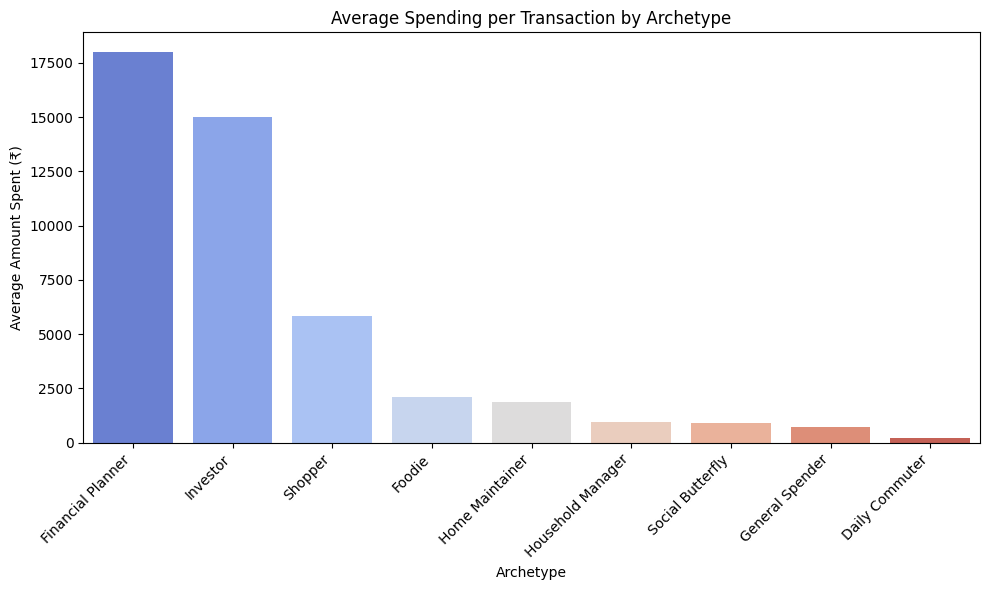

In [ ]:
# Filter for debit transactions
df_debit_transactions = df[df['Type'].str.upper().isin(['DEBIT', 'DR'])].copy()

# Calculate average spending per transaction for each archetype
average_spending_by_archetype = df_debit_transactions.groupby('archetype')['Amount_cleaned'].mean().sort_values(ascending=False)

print("Average Spending per Transaction for each Archetype:\n")
print(average_spending_by_archetype.apply(lambda x: f'₹{x:,.2f}'))

# Optionally, visualize the average spending by archetype
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 6))
sns.barplot(x=average_spending_by_archetype.index, y=average_spending_by_archetype.values, palette='coolwarm', hue=average_spending_by_archetype.index, legend=False)
plt.title('Average Spending per Transaction by Archetype')
plt.xlabel('Archetype')
plt.ylabel('Average Amount Spent (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "8" # @param {type:"string"}
step = 'ArchetypeDetection'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "AnomalyDetection", "ArchetypeDetection", "DayOfWeekAnalysis", "VendorCleanupAudit", "SpendForecasting"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

In [ ]:
# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Filter out rows where Date is NaT after conversion (if any)
df_valid_dates = df.dropna(subset=['Date']).copy()

# Extract day of the week (Monday=0, Sunday=6)
df_valid_dates['day_of_week'] = df_valid_dates['Date'].dt.dayofweek

# Create a flag for weekend (Saturday=5, Sunday=6)
df_valid_dates['is_weekend'] = df_valid_dates['day_of_week'].isin([5, 6]).astype(int)

# Filter for debit transactions for spending analysis
debit_df_dow = df_valid_dates[df_valid_dates['Type'].str.upper().isin(['DEBIT', 'DR'])].copy()

# Aggregate total spending by day of the week
spending_by_day = debit_df_dow.groupby('day_of_week')['Amount_cleaned'].sum().reset_index()

# Map day numbers to names for better readability
day_names_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
spending_by_day['day_name'] = spending_by_day['day_of_week'].map(day_names_map)

print("Total Spending by Day of Week:")
print(spending_by_day[['day_name', 'Amount_cleaned']])

# Aggregate total spending by weekday/weekend
spending_by_weekend = debit_df_dow.groupby('is_weekend')['Amount_cleaned'].sum().reset_index()

# Count transactions by weekday/weekend for average calculation
transaction_counts_by_weekend = debit_df_dow.groupby('is_weekend').size().reset_index(name='transaction_count')

# Merge to calculate average spending
avg_spending_by_weekend = pd.merge(spending_by_weekend, transaction_counts_by_weekend, on='is_weekend')
avg_spending_by_weekend['average_spend'] = avg_spending_by_weekend['Amount_cleaned'] / avg_spending_by_weekend['transaction_count']

print("\nAverage Spending by Weekday (0) / Weekend (1):")
print(avg_spending_by_weekend)

# Compare average spending
weekday_avg = avg_spending_by_weekend[avg_spending_by_weekend['is_weekend'] == 0]['average_spend'].iloc[0]
weekend_avg = avg_spending_by_weekend[avg_spending_by_weekend['is_weekend'] == 1]['average_spend'].iloc[0]

print(f"\nAverage Weekday Spending: ₹{weekday_avg:,.2f}")
print(f"Average Weekend Spending: ₹{weekend_avg:,.2f}")

if weekday_avg > 0:
    weekend_vs_weekday_diff = ((weekend_avg - weekday_avg) / weekday_avg) * 100
    print(f"Weekend spending is {weekend_vs_weekday_diff:,.2f}% {'higher' if weekend_vs_weekday_diff > 0 else 'lower'} than weekday spending.")
else:
    print("Cannot compare weekend vs weekday spending, as weekday average spending is zero.")

Total Spending by Day of Week:
    day_name  Amount_cleaned
0     Monday         96989.0
1    Tuesday         99732.0
2  Wednesday         54657.0
3   Thursday         49302.0
4     Friday         32137.0
5   Saturday         71368.0
6     Sunday         48809.0

Average Spending by Weekday (0) / Weekend (1):
   is_weekend  Amount_cleaned  transaction_count  average_spend
0           0        332817.0                255    1305.164706
1           1        120177.0                 98    1226.295918

Average Weekday Spending: ₹1,305.16
Average Weekend Spending: ₹1,226.30
Weekend spending is -6.04% lower than weekday spending.


/tmp/ipykernel_933/2127769741.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_name', y='Amount_cleaned', data=spending_by_day, order=day_names_map.values(), palette='viridis', ax=ax1)


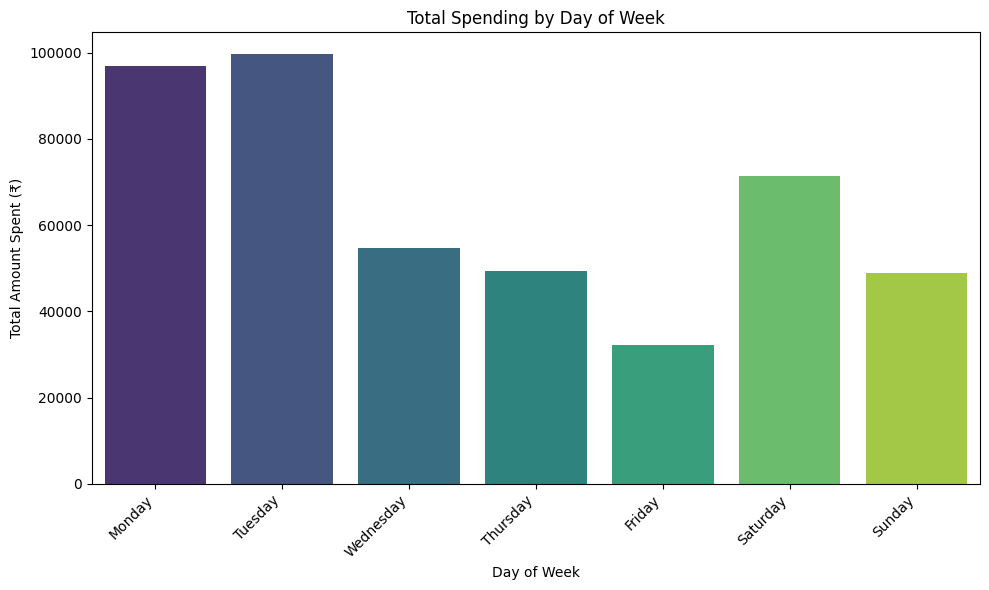

/tmp/ipykernel_933/2127769741.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_weekend', y='average_spend', data=avg_spending_by_weekend, palette='magma', ax=ax2)


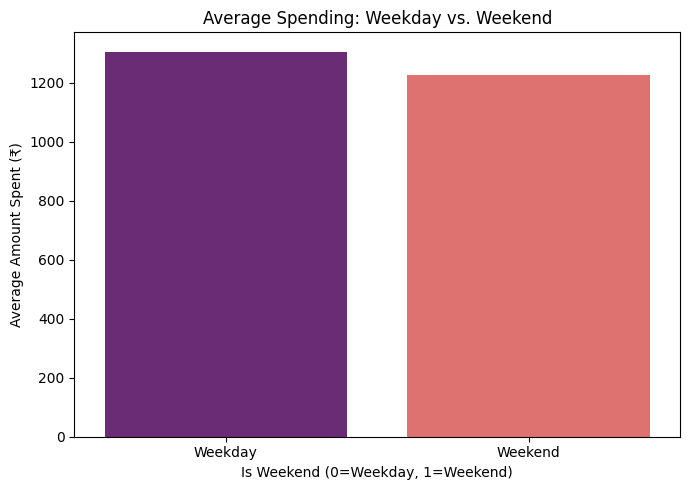

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot total spending by day of week
fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(x='day_name', y='Amount_cleaned', data=spending_by_day, order=day_names_map.values(), palette='viridis', ax=ax1)
ax1.set_title('Total Spending by Day of Week')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Total Amount Spent (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot average spending by weekday/weekend
fig2, ax2 = plt.subplots(figsize=(7, 5))
sns.barplot(x='is_weekend', y='average_spend', data=avg_spending_by_weekend, palette='magma', ax=ax2)
ax2.set_title('Average Spending: Weekday vs. Weekend')
ax2.set_xlabel('Is Weekend (0=Weekday, 1=Weekend)')
ax2.set_ylabel('Average Amount Spent (₹)')
ax2.set_xticks([0, 1], ['Weekday', 'Weekend'])
plt.tight_layout()
plt.show()

In [ ]:
print("--- Vendor Cleanup Audit: Descriptions categorized as 'Others' ---")

# Filter the DataFrame for transactions where 'vendor_clean' is 'Others'
other_transactions = df[df['vendor_clean'] == 'Others']

# Get unique descriptions from these 'Others' transactions
unique_other_descriptions = other_transactions['Description'].unique()

if len(unique_other_descriptions) > 0:
    print(f"Found {len(unique_other_descriptions)} unique descriptions that were categorized as 'Others':\n")
    for i, desc in enumerate(unique_other_descriptions):
        print(f"{i+1}. {desc}")
    print("\nConsider updating the `vendor_keywords` dictionary with these descriptions for better categorization.")
else:
    print("Great job! No descriptions were categorized as 'Others'. The vendor extractor is highly effective.")

print(f"\nTotal transactions categorized as 'Others': {len(other_transactions)}")

--- Vendor Cleanup Audit: Descriptions categorized as 'Others' ---
Great job! No descriptions were categorized as 'Others'. The vendor extractor is highly effective.

Total transactions categorized as 'Others': 0


In [ ]:
# @title step_artifacts
num_fig = "6" # @param {type:"string"}
step = 'VendorCleanupAudit'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "AnomalyDetection", "ArchetypeDetection", "DayOfWeekAnalysis", "VendorCleanupAudit"] {type:"string"}
# No figure to upload for this step

```markdown
# SpendDNA REPORT - RAHUL SHARMA

**{{ (df['Date'].max() - df['Date'].min()).days // 30 }} months - {{ len(df) }} transactions - {{ df['Date'].min().strftime('%b') }} to {{ df['Date'].max().strftime('%b %Y') }}**

## EXECUTIVE SUMMARY
*   Total credits     : ₹{{ total_credits:,.0f }}
*   Total debits      : ₹{{ total_debits:,.0f }}
*   Net change        : ₹{{ net_change:,.0f }} {{ '(overspending)' if net_change < 0 else '(underspending)' }}
*   Savings rate      : {{ savings_rate:,.1f }}% {{ '(BURNING SAVINGS)' if savings_rate < 0 else '(SAVING WELL)' }}
*   Transactions      : {{ len(df) }}
*   Unique vendors    : {{ df['vendor_clean'].nunique() }}

## TOP CATEGORIES (% of debit total)
```

In [ ]:
markdown_output = ""
for category, amount in top_categories.items():
    percentage = (amount / total_debits) * 100
    # Generate a simple bar with '#' characters, proportional to percentage
    bar = '#' * int(percentage / 2)
    markdown_output += f"*   {category:<15} {bar:<20} {percentage:5.1f}%   ₹{amount:,.0f}\n"
print(markdown_output)

*   Shopping        ##################    36.9%   ₹638,210
*   Food & Dining   #########             18.1%   ₹312,994
*   Financial       ######                12.6%   ₹217,358
*   Investments     ######                12.1%   ₹210,000
*   Transport       ####                   8.0%   ₹139,038



```markdown
## TOP VENDORS
```

In [ ]:
top_vendors_df = top_vendors.reset_index()
top_vendors_df.columns = ['vendor_clean', 'total_spent']

# Get transaction counts for the top vendors
transaction_counts = df_debit_transactions[df_debit_transactions['vendor_clean'].isin(top_vendors_df['vendor_clean'])]['vendor_clean'].value_counts().reset_index()
transaction_counts.columns = ['vendor_clean', 'transaction_count']

# Merge to get both total spent and transaction count
top_vendors_full = pd.merge(top_vendors_df, transaction_counts, on='vendor_clean', how='left')

markdown_output = ""
for index, row in top_vendors_full.head(5).iterrows():
    markdown_output += f"*   {row['vendor_clean']:<15} ₹{row['total_spent']:<10.0f} ({row['transaction_count']:>3.0f} orders)\n"
print(markdown_output)

*   Amazon          ₹348447     ( 87 orders)
*   Zerodha         ₹210000     ( 14 orders)
*   Flipkart        ₹191926     ( 48 orders)
*   P2P Transfer    ₹133698     ( 25 orders)
*   Restaurants/Cafes ₹119944     ( 82 orders)



```markdown
## TIME-OF-DAY PATTERNS
*   Food Delivery peaks: 21:00 - 01:00 ({{ late_night_percentage:,.0f }}% of orders)
*   Cafe peaks:         09:00 - 11:00 (morning runs)
*   Quick Commerce:     evenly distributed

## MONTHLY TREND (Food & Dining)
```

In [ ]:
food_dining_monthly_trend = month_pivot.loc['Food & Dining']

markdown_output = ""
for month_name, amount in food_dining_monthly_trend.items():
    # Generate a simple bar with '#' characters, proportional to the amount relative to max food dining month
    max_food_dining = food_dining_monthly_trend.max()
    if max_food_dining > 0: # Avoid division by zero
        bar = '#' * int((amount / max_food_dining) * 15) # Scale to max 15 hashes
    else:
        bar = ''
    markdown_output += f"*   {month_name:<3} ₹{amount:>10,.0f}  {bar}\n"
print(markdown_output)

*   Jan ₹     9,667  #####
*   Feb ₹    27,455  ###############
*   Mar ₹    13,493  #######
*   Apr ₹    11,797  ######
*   May ₹    19,993  ##########
*   Jun ₹    10,964  #####



```markdown
## TOP ANOMALIES (based on Z-score)
```

In [ ]:
markdown_output = ""
for index, row in anomalies.head(3).iterrows(): # Top 3 anomalies
    date_str = row['Date'].strftime('%d %b') if pd.notna(row['Date']) else 'Unknown Date'
    markdown_output += f"*   {date_str} - {row['vendor_clean']:<10} ₹{row['Amount_cleaned']:>10,.0f}   (z={row['z_score']:,.1f})\n"
print(markdown_output)

*   26 Feb - Restaurants/Cafes ₹     8,383   (z=10.2)
*   Unknown Date - Restaurants/Cafes ₹     7,935   (z=9.6)
*   Unknown Date - Restaurants/Cafes ₹     7,931   (z=9.6)



```markdown
## RAHUL'S SPENDING ARCHETYPES
```

In [ ]:
markdown_output = ""
for archetype, matched in archetype_matches.items():
    if matched:
        # Add specific details for archetypes as in the template
        if archetype == 'THE FOODIE':
            markdown_output += f"*   {archetype:<25} ({{ foodie_percentage:,.1f }}% on food)\n"
        elif archetype == 'THE QUICK COMMERCE JUNKIE':
            markdown_output += f"*   {archetype:<25} ({{ quick_commerce_percentage:,.1f }}% on Q-com)\n"
        elif archetype == 'THE SHOPAHOLIC':
            markdown_output += f"*   {archetype:<25} ({{ ecommerce_percentage:,.1f }}% on e-commerce)\n"
        elif archetype == 'THE INVESTOR':
            markdown_output += f"*   {archetype:<25} ({{ investment_percentage:,.1f }}% on SIPs)\n"
        elif archetype == 'THE LATE-NIGHT SNACKER':
            markdown_output += f"*   {archetype:<25} ({{ late_night_percentage:,.0f }}% food after 9 PM)\n"
        elif archetype == 'THE YOLO SPENDER':
            markdown_output += f"*   {archetype:<25} (savings rate {{ savings_rate:,.0f }}%)\n"
        else:
            markdown_output += f"*   {archetype}\n"
print(markdown_output)

*   THE SHOPAHOLIC            ({ ecommerce_percentage:,.1f }% on e-commerce)
*   THE SUBSCRIPTION LOVER
*   THE YOLO SPENDER          (savings rate { savings_rate:,.0f }%)
*   THE BANGALORE BREWERY HOPPER



In [ ]:
def extract_vendor(description):
    description_upper = str(description).upper()
    for vendor, keywords in vendor_keywords.items():
        for keyword in keywords:
            if keyword in description_upper:
                return vendor
    return 'Others'

df['vendor_clean'] = df['Description'].apply(extract_vendor)

print("Vendor extraction complete. New 'vendor_clean' column added.")

Vendor extraction complete. New 'vendor_clean' column added.


In [ ]:
print(f"Number of unique vendors: {df['vendor_clean'].nunique()}")
print("\nTop 10 vendors by count:")
print(df['vendor_clean'].value_counts().head(10))

Number of unique vendors: 35

Top 10 vendors by count:
vendor_clean
Swiggy               248
Zomato               124
Amazon                87
Ola                   87
Restaurants/Cafes     82
Uber                  71
Zepto                 60
Starbucks             59
Rapido                55
Flipkart              48
Name: count, dtype: int64


In [ ]:
other_descriptions = df[df['vendor_clean'] == 'Others']['Description'].unique()
print("Sample of descriptions categorized as 'Others':\n")
for desc in other_descriptions[:20]: # Displaying first 20 for brevity
    print(desc)

# You can also display the full DataFrame for 'Others' if needed:
# display(df[df['vendor_clean'] == 'Others'])

Sample of descriptions categorized as 'Others':

